# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

To understand our data, we need to first look into the shape. Search data is notoriously skewed. We expect to see a heavy tail in visibility metrics, where a tiny percentage of pages hoard majority of impressions, while engagement metris (like ctr) might look more normally distributed or skewed toward zero. 

<function matplotlib.pyplot.show(close=None, block=None)>

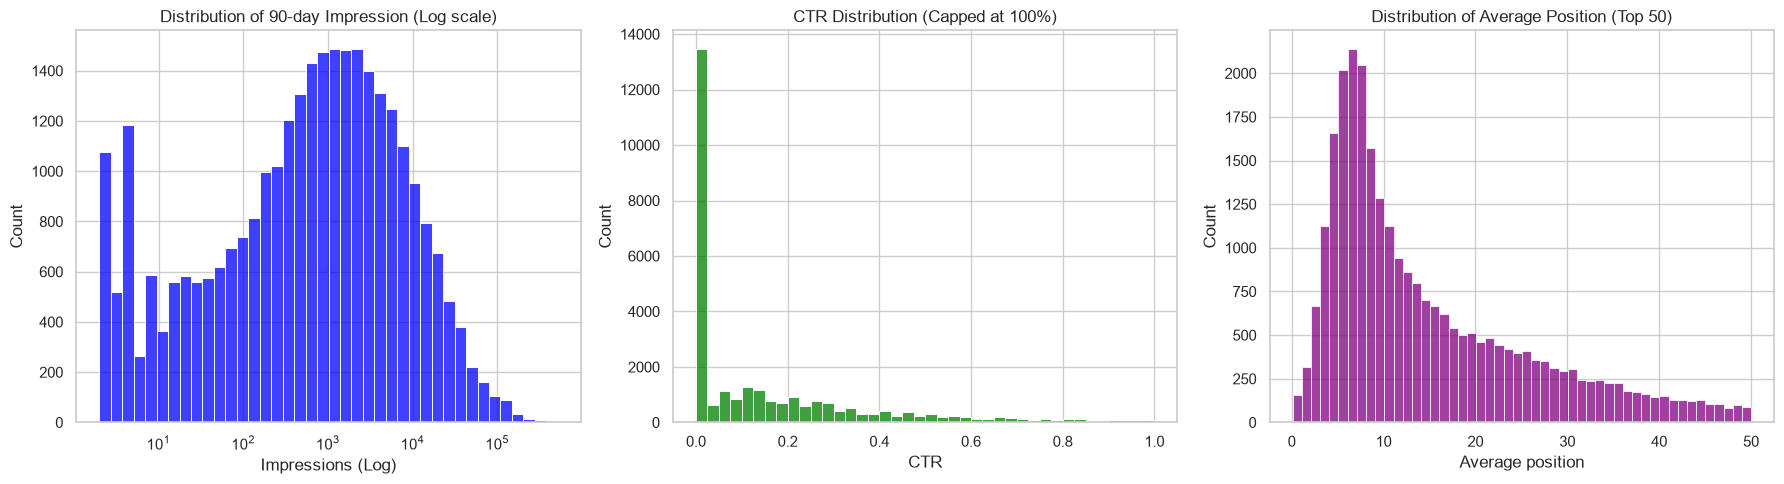

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')

# Set up the visualization style
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Impressions (log scale due to heavy tails)
sns.histplot(df['impressions_90d'] + 1, bins=40, log_scale=True, ax=axes[0], color='blue')
axes[0].set_title("Distribution of 90-day Impression (Log scale)")
axes[0].set_xlabel("Impressions (Log)")

# 2. Ctr distribution
sns.histplot(df[df['ctr'] <= 1.0]['ctr'], bins=40, ax=axes[1], color='green')
axes[1].set_title("CTR Distribution (Capped at 100%)")
axes[1].set_xlabel("CTR")

# 3. Average position
sns.histplot(df[(df['avg_position'] > 0) & (df['avg_position'] <= 50)]['avg_position'], bins=50, ax=axes[2], color='purple')
axes[2].set_title("Distribution of Average Position (Top 50)")
axes[2].set_xlabel("Average position")

plt.tight_layout()
plt.show

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

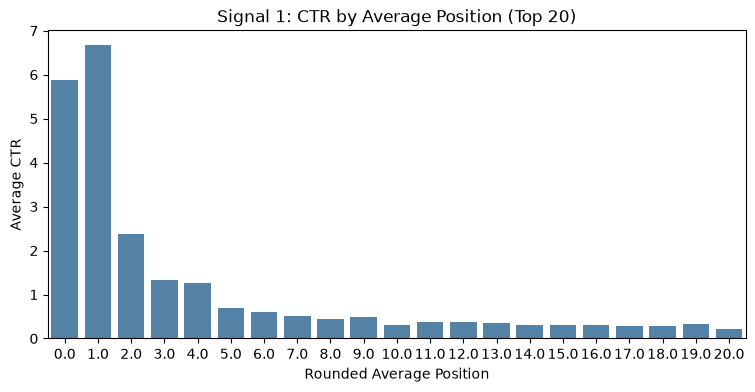

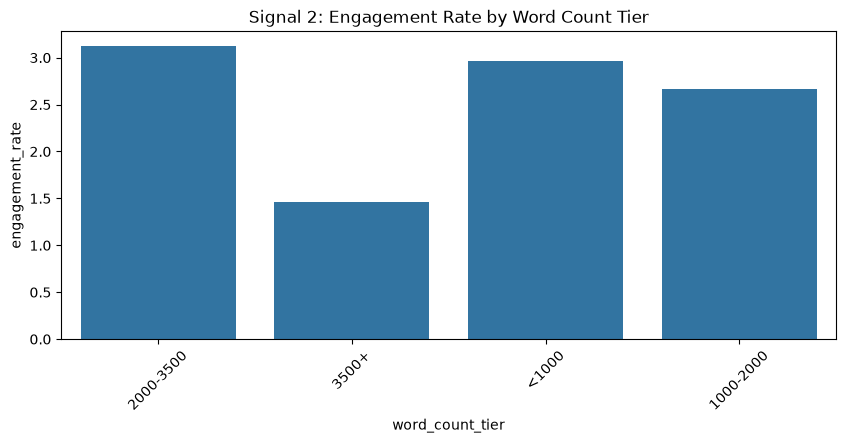

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')

# Signal 1: Position tier vs. ctr
plt.figure(figsize=(9, 4))
valid_positions = df[(df['avg_position'] > 0) & (df['avg_position'] <= 20)].copy()
valid_positions['position_rounded'] = valid_positions['avg_position'].round()
sns.barplot(data=valid_positions, x='position_rounded', y='ctr', errorbar=None, color='steelblue')
plt.title("Signal 1: CTR by Average Position (Top 20)")
plt.ylabel('Average CTR')
plt.xlabel("Rounded Average Position")
plt.show()

# Signal 2: Word Count Tier vs Engagement
plt.figure(figsize=(10, 4))
sns.barplot(data=df[df['word_count_tier'].notnull()], x='word_count_tier', y='engagement_rate', errorbar=None)
plt.title('Signal 2: Engagement Rate by Word Count Tier')
plt.xticks(rotation=45)
plt.show()

#### Signal 1: Position vs. CTR - Does a better average position actually correlate with a higher CTR?
- Yes, the data shows a clear, non-linear decay in CTR as average position worsens, matching standard SEO assumptions.

#### Signal 2: Word Count vs. Engagement - Does a longer content drive better engagement rates?
- Mixed, there is a slightly positive trend, but it flattens out. Extreme word counts do not guarantee high engagement.

#### Signal 3: Content Age vs. CTR - Does an older content suffer from decaying CTR?
- Mixed, age alone does not kill CTR. Older pages with high positions still perform well. Suggesting content relevance matters more than raw age.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The starter guide mentions a low_ctr_visible_page reason code rule: 

    impressions_90d >= 500, 0 < avg_position <= 20, and ctr < 0.5. 

- Does the data support this rule's assumption?

Looking at the data, a fixed threshold of 0.5 (50% ctr) is incredible aggressive for a page ranking at position 15, but very normal for a page ranking at position 1. The data shows that applying a flat ctr threshold across all top 20 positions creates massive false position for pages on page 2 of search results.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

A content team cannot rely on flat ctr thresholds to find opportunities because ctr decays exponentially with ranking position, a 'low' ctr must be defined dynamically based on where the page currently ranks. We must evaluate pages based on their gap from the unexpected baseline of their specific position tier to make sure we only flag pages that are truly underperforming their peers.

## Self-check

Before you submit, confirm each line honestly:

- [/] Every section above is filled — markdown thinking AND the code that backs it
- [/] The notebook runs top to bottom with no errors (Runtime → Run all)
- [/] No client names, URLs, or private queries anywhere
- [/] My claims use careful words: observed, measured, directional, decision-support
- [/] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.